In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns
from openpyxl import load_workbook
from openpyxl.drawing.image import Image
from openpyxl.styles import Border, Side, Alignment, Font
from openpyxl.utils import get_column_letter
from scipy.stats import beta
from scipy.optimize import curve_fit
import copy

from sklearn.metrics import r2_score

from collections import defaultdict
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')



In [2]:
def load_weather(weather_path, start_year, end_year):    
    # Load the "Hourly" weather data
    
    weather_data = pd.read_csv(weather_path)
    # Slicing the weather data to the dates within the observation year
    weather_data['Date'] = pd.to_datetime(weather_data['Date'], format="%d/%m/%Y", errors='coerce')
    weather_data = weather_data[
        (pd.to_datetime(weather_data['Date'],format="%d/%m/%Y") >= pd.to_datetime(f'{start_year}-1-1')) &
        (pd.to_datetime(weather_data['Date'],format="%d/%m/%Y") <= pd.to_datetime(f'{end_year}-12-31'))]       
    # Renaming the columns and add doy column         
    weather_data = weather_data[['Date', 'Time', 'Temp']].rename(columns={'Date': 'date', 'Time':'Time', 'Temp':'temp'}, inplace=False)
    weather_data.insert(1, 'doy', [d.dayofyear for d in pd.to_datetime(weather_data['date'], format="%d/%m/%Y")])
    # Interpolate missing values
    # Convert '-' to NaN
    weather_data['temp'].replace('-', np.nan, inplace=True)
    weather_data['temp']=weather_data['temp'].apply(pd.to_numeric, errors='coerce')

    # Interpolate missing values
    if weather_data['temp'].isna().any():
        weather_data['temp'].interpolate(method='linear', inplace=True)


    return weather_data.reset_index(drop=True) 

# For single temperature values
def Wangengel(T, MinTemp,OptTemp,MaxTemp,RefTemp):
    RelEff = 0.0
    RelEffRefTemp = 1.0
    p = 0.0

    if MinTemp < T < MaxTemp:
        p = math.log(2.0) / math.log((MaxTemp - MinTemp) / (OptTemp - MinTemp))
        RelEff = (2 * (T - MinTemp) ** p * (OptTemp - MinTemp) ** p - (T - MinTemp) ** (2 * p)) / (OptTemp - MinTemp) ** (2 * p)

    if MinTemp < RefTemp < MaxTemp:
        p = math.log(2.0) / math.log((MaxTemp - MinTemp) / (OptTemp - MinTemp))
        RelEffRefTemp = (2 * (RefTemp - MinTemp) ** p * (OptTemp - MinTemp) ** p - (RefTemp - MinTemp) ** (2 * p)) / (OptTemp - MinTemp) ** (2 * p)

    return float(RelEff / RelEffRefTemp)


def linear_relationship(x,a,b):
    return a*x + b

def sigmoid(x,
            y_min,
            y_max,
            b,
            x_crit):
    return y_min + (y_max - y_min) / (
        1.0 + np.exp(-(x - x_crit)/b))

def asymmetric_gaussian(x, A, mu, sigma_left, sigma_right):
    sigma = np.where(x < mu, sigma_left, sigma_right)
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

In [3]:
file_path = './KRIP_hayward_fruit_quality_data/20260522_DatasetForJemBurdon_MaturityAreaPredictions2026_YieldAndProfileAdded.xlsx'
xls = pd.ExcelFile(file_path, engine="openpyxl")
Report_HwMaturityAreas = pd.read_excel(xls, sheet_name = 'HwMaturityAreas')
Report_YieldAndProfileData = pd.read_excel(xls, sheet_name = 'YieldAndProfileData')

In [4]:
# list_of_interested_columns = ['GrowerMaCode',
#                               'Sum of Season',
#                             'FullBloomDate',
#                             'ClearToPickDate',
#                             'Sum of Brix',
#                             'Sum of DryMatter',
#                             'Sum of GirdleCountSize',
#                             'Sum of GirdleCountDryMatter']

Report_HwMaturityAreas_2DMGirdles = Report_HwMaturityAreas[(Report_HwMaturityAreas['Sum of GirdleCountDryMatter']==2)].reset_index(drop=True)

Report_YieldAndProfileData_2DMGirdles = Report_YieldAndProfileData.merge(
    Report_HwMaturityAreas_2DMGirdles[['GrowerMaCode', 'Sum of Season', 'FullBloomDate', 'ClearToPickDate', 'Sum of DryMatter']],
    left_on=['GrowerMaturityAreaKey', 'Season'],
    right_on=['GrowerMaCode', 'Sum of Season'],
    how='inner'
).reset_index(drop=True)


In [6]:
SizeCodeToKg ={'Size18_Perc': np.mean([0.180,0.210]),
            'Size22_Perc': np.mean([0.150,0.180]),
            'Size25_Perc': np.mean([0.138,0.150]),
            'Size27_Perc': np.mean([0.128,0.138]),
            'Size30_Perc': np.mean([0.118,0.128]),
            'Size33_Perc': np.mean([0.106,0.118]),
            'Size36_Perc': np.mean([0.091,0.106]),
            'Size39_Perc': np.mean([0.082,0.091]),
            'Size42_Perc': np.mean([0.074,0.082]),
            'Size46_Perc': np.mean([0.072,0.074])}

In [49]:
# THERMAL TIME ACCUMULATION
##########################################
weather_df = defaultdict(lambda: defaultdict(lambda: dict()))
weather_path= {'Kerikeri': "C:/Users/hranfs/Documents/VS code/Weather/Kerikeri_interpolated_hourly_2007_2024.csv",
                'Te Puke': "C:/Users/hranfs/Documents/VS code/Weather/Te Puke_interpolated_hourly_2007_2025.csv"}

location = 'Te Puke'

RequiredTT = []
fruit_num_all_sizes = []
DW_g = []
FW_g = []

for i in range(len(Report_YieldAndProfileData_2DMGirdles)):
    # FullBloom & Picking Dates
    FullBloomDate = pd.to_datetime(Report_YieldAndProfileData_2DMGirdles['FullBloomDate'].iloc[i])
    ClearToPickDate = pd.to_datetime(Report_YieldAndProfileData_2DMGirdles['ClearToPickDate'].iloc[i])
    FW_g.append(SizeCodeToKg[Report_YieldAndProfileData_2DMGirdles[SizeCodeToKg.keys()].iloc[i].idxmax()]*1000)
    DW_g.append(Report_YieldAndProfileData_2DMGirdles['Sum of DryMatter'].iloc[i]/100 * SizeCodeToKg[Report_YieldAndProfileData_2DMGirdles[SizeCodeToKg.keys()].iloc[i].idxmax()]*1000)
    # Fruit number & DW calculation
    hec_to_m2 = 1e-4
    fruits_per_m2_per_size = 0
    kg_per_hec = Report_YieldAndProfileData_2DMGirdles[SizeCodeToKg.keys()].iloc[i] * Report_YieldAndProfileData_2DMGirdles['TotalKgsPerHa'].iloc[i]
    for size in kg_per_hec.index:
        fruit_num_per_size = kg_per_hec[size] / SizeCodeToKg[size] * hec_to_m2
        fruits_per_m2_per_size += fruit_num_per_size

    fruit_num_all_sizes.append(fruits_per_m2_per_size)
    

    # FullBloom & Picking Years
    flowering_year = FullBloomDate.year
    fruiting_year = ClearToPickDate.year 

    # Load the weather data
    weather_data = load_weather(weather_path[location], flowering_year, fruiting_year)
    weather_data['date'] = pd.to_datetime(weather_data['date'], format="%d/%m/%Y") 
    weather_since_start_doy = weather_data[(weather_data['date']>=FullBloomDate) & (weather_data['date'] <=ClearToPickDate)].reset_index(drop=True)  
    
    TT = 0
    for temp in weather_since_start_doy['temp']:
        TT += Wangengel(temp, MinTemp=8.5,OptTemp=19,MaxTemp=33,RefTemp=19)

    RequiredTT.append(TT)

# Add to the calculated dato to the DF
Report_YieldAndProfileData_2DMGirdles['Fruit Num'] = fruit_num_all_sizes
Report_YieldAndProfileData_2DMGirdles['DW'] = DW_g
Report_YieldAndProfileData_2DMGirdles['FW'] = FW_g
Report_YieldAndProfileData_2DMGirdles['RequiredTT'] = RequiredTT
    

In [60]:
Report_YieldAndProfileData_2DMGirdles

,GrowerMaturityAreaKey,Season,TotalKgsPerHa,Size16_Perc,Size18_Perc,Size22_Perc,Size25_Perc,Size27_Perc,Size30_Perc,Size33_Perc,...,Packout_Class1_Perc,GrowerMaCode,Sum of Season,FullBloomDate,ClearToPickDate,Sum of DryMatter,Fruit Num,DW,RequiredTT,FW
0,18966_1,2023,38255.000000,NaN,0.002986,0.093425,0.156845,0.196452,0.197034,0.196000,...,0.857363,18966_1,2023,2022-11-23,2023-05-24,17.8,31.172860,21.8940,3791.482729,123.0
1,18966_3,2023,42193.010753,NaN,0.001319,0.055616,0.109193,0.160048,0.189481,0.230357,...,0.844593,18966_3,2023,2022-11-23,2023-05-24,17.6,36.298726,19.7120,3791.482729,112.0
2,18966_4,2023,39957.681159,NaN,0.001627,0.047818,0.104415,0.147991,0.182087,0.245223,...,0.812199,18966_4,2023,2022-11-23,2023-05-24,17.1,34.694903,19.1520,3791.482729,112.0
3,57575_1,2025,59656.979167,NaN,0.000201,0.014829,0.049508,0.098777,0.174027,0.277621,...,0.948078,57575_1,2025,2024-11-12,2025-04-10,18.0,54.542875,17.7300,3202.506124,98.5
4,57575_1,2024,44744.791667,NaN,0.000856,0.036138,0.088970,0.141465,0.195298,0.244679,...,0.891104,57575_1,2024,2023-11-09,2024-04-08,17.3,39.369246,19.3760,3154.114645,112.0
5,57575_1,2023,30835.104167,NaN,0.007201,0.139404,0.195584,0.197633,0.188522,0.159340,...,0.892986,57575_1,2023,2022-11-12,2023-04-06,18.1,24.227998,24.0730,3147.648273,133.0
6,57575_2,2025,50873.796296,NaN,0.000324,0.006781,0.021225,0.045596,0.103143,0.212049,...,0.904880,57575_2,2025,2024-11-12,2025-03-31,17.9,50.447172,17.6315,2995.205330,98.5
7,57575_2,2024,40090.509259,NaN,0.000842,0.025216,0.058563,0.106097,0.155876,0.233552,...,0.891453,57575_2,2024,2023-11-09,2024-04-01,17.5,37.160794,17.2375,3008.660497,98.5
8,57575_3,2025,57181.875000,NaN,0.000193,0.008803,0.027835,0.063086,0.122609,0.233736,...,0.914613,57575_3,2025,2024-11-12,2025-04-03,17.5,55.261228,17.2375,3061.979764,98.5
9,57575_3,2024,36561.281250,NaN,0.001109,0.030562,0.071468,0.111256,0.160733,0.229613,...,0.919445,57575_3,2024,2023-11-09,2024-04-01,17.2,33.523513,16.9420,3008.660497,98.5


In [77]:
Report_YieldAndProfileData_2DMGirdles[(Report_YieldAndProfileData_2DMGirdles['GrowerMaturityAreaKey'].isin(['75554_F','75554_G'])) & (Report_YieldAndProfileData_2DMGirdles['Season']==2025)]['FW'].mean()

np.float64(98.5)

In [38]:
data_x = copy.deepcopy(RequiredTT)

data_y = list(copy.deepcopy(Report_YieldAndProfileData_2DMGirdles['Sum of DryMatter']))


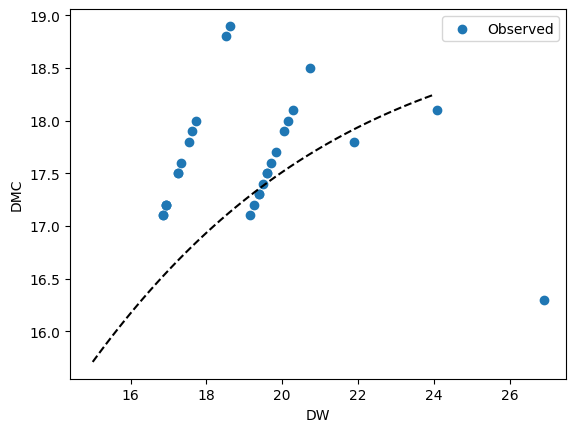

In [29]:
# [d*r for d,r in zip(DW_g,RequiredTT)]
plt.scatter(Report_YieldAndProfileData_2DMGirdles['DW'] , Report_YieldAndProfileData_2DMGirdles['Sum of DryMatter'], label='Observed')
plt.xlabel('DW')
plt.ylabel('DMC')
plt.legend()

def ssc_sigmoid(CT,
                SSC_min,
                SSC_max,
                b,
                CT_crit):
    """
    Sigmoid SSC accumulation for Hayward kiwifruit.
    
    Parameters (R2=0.87)
    ----------
    CT : float or array
        Cumulative cool time
    SSC_min : float: 
        Lower asymptote (°Brix)
    SSC_max : float: 
        Upper asymptote (°Brix)
    b : float: 
        Inverse of Sigmoid slope
    CT_crit : float: 
        Inflection point
    
    Returns
    -------
    SSC : float or array
        Simulated soluble solids content (°Brix)
    """
    return SSC_min + (SSC_max - SSC_min) / (
        1.0 + np.exp(-(CT - CT_crit)/b))

# bounds = [(4,13.5,130,600),(4.55,13.75,140,850)]
# popt, _ = curve_fit(ssc_sigmoid, data_x, data_y, bounds=bounds)

x = np.linspace(15,24,100)
plt.plot(x, ssc_sigmoid(x, 0, 19, 5.54, 6.34), 'k--')
# print(r2_score(data_y, [ssc_sigmoid(i, popt[0], popt[1],popt[2], popt[3]) for i in data_x]))
# print(popt[0], popt[1],popt[2], popt[3])

29